# Basic Exploratory Data Analysis (EDA)
This notebook performs basic EDA on the recipes and reviews dataset from the `archive` folder, as well as the `full_dataset.csv` from the `dataset` folder, to answer the following questions:
1. Number of users
2. Number of recipes
3. Number of interactions
4. Rating distribution
5. Top recipes
6. Missing values
7. Recipe categories
8. Nutrition field availability

## Part 1: Archive Dataset Analysis
These datasets (`recipes.csv` and `reviews.csv`) contain the specific fields required for user interaction, ratings, and nutrition analysis.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load archive data
recipes = pd.read_csv('archive/recipes.csv')
reviews = pd.read_csv('archive/reviews.csv')

In [14]:
# 1. Number of users
recipe_users = set(recipes['AuthorId'].dropna().unique())
review_users = set(reviews['AuthorId'].dropna().unique())
total_users = len(recipe_users.union(review_users))
print(f"Total unique users: {total_users}")

Total unique users: 299892


In [15]:
# 2. Number of recipes
total_recipes = recipes['RecipeId'].nunique()
print(f"Total recipes: {total_recipes}")

Total recipes: 522517


In [16]:
# 3. Number of interactions
total_interactions = len(reviews)
print(f"Total interactions (reviews): {total_interactions}")

Total interactions (reviews): 1401982


C:\Users\krina\AppData\Local\Temp\ipykernel_18452\1148649315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews, x='Rating', palette='viridis')


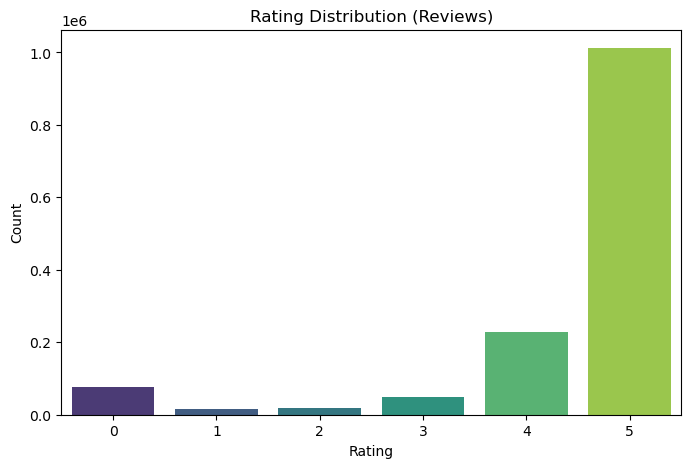

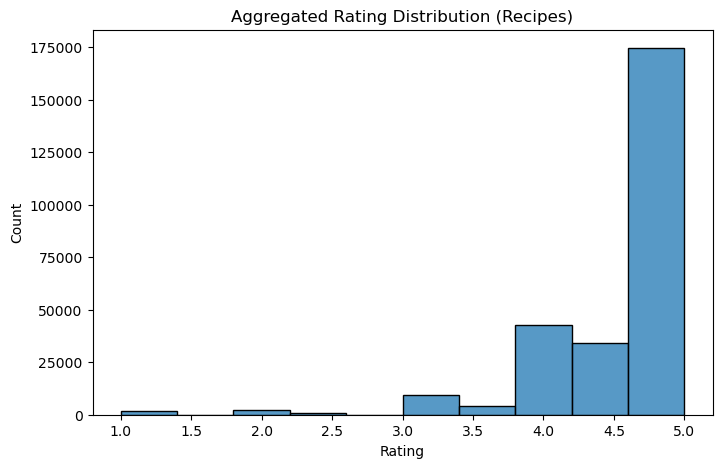

In [17]:
# 4. Rating distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=reviews, x='Rating', palette='viridis')
plt.title('Rating Distribution (Reviews)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(recipes['AggregatedRating'].dropna(), bins=10, kde=False)
plt.title('Aggregated Rating Distribution (Recipes)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [18]:
# 5. Top recipes
# Based on review count and aggregated rating
top_recipes = recipes.sort_values(by=['ReviewCount', 'AggregatedRating'], ascending=[False, False]).head(10)
print("Top 10 Recipes:")
display(top_recipes[['Name', 'ReviewCount', 'AggregatedRating']])

Top 10 Recipes:


,Name,ReviewCount,AggregatedRating
41924,Bourbon Chicken,3063.0,5.0
1436,Best Banana Bread,2273.0,5.0
23725,To Die for Crock Pot Roast,1692.0,5.0
84057,Crock-Pot Chicken With Black Beans &amp; Cream...,1657.0,4.5
35377,Creamy Cajun Chicken Pasta,1586.0,5.0
32174,Oatmeal Raisin Cookies,1410.0,5.0
62823,Best Ever Banana Cake With Cream Cheese Frosting,1409.0,5.0
50172,"Yes, Virginia There is a Great Meatloaf",1384.0,5.0
19387,Jo Mama's World Famous Spaghetti,1326.0,5.0
28625,&quot;Whatever Floats Your Boat&quot; Brownies!,1284.0,5.0


In [19]:
# 6. Missing values
print("Missing values in Recipes:")
print(recipes.isnull().sum())
print("\nMissing values in Reviews:")
print(reviews.isnull().sum())

Missing values in Recipes:
RecipeId                           0
Name                               0
AuthorId                           0
AuthorName                         0
CookTime                       82545
PrepTime                           0
TotalTime                          0
DatePublished                      0
Description                        5
Images                             1
RecipeCategory                   751
Keywords                       17237
RecipeIngredientQuantities         3
RecipeIngredientParts              0
AggregatedRating              253223
ReviewCount                   247489
Calories                           0
FatContent                         0
SaturatedFatContent                0
CholesterolContent                 0
SodiumContent                      0
CarbohydrateContent                0
FiberContent                       0
SugarContent                       0
ProteinContent                     0
RecipeServings                182911
RecipeYield

Top 20 Recipe Categories:
RecipeCategory
Dessert           62072
Lunch/Snacks      32586
One Dish Meal     31345
Vegetable         27231
Breakfast         21101
Beverages         16076
Chicken           13249
Meat              13131
Breads            12804
Pork              12603
Sauces            12166
Chicken Breast    11282
Potato            10870
Quick Breads      10387
< 60 Mins          9719
< 30 Mins          9020
Cheese             8462
Pie                7775
Bar Cookie         7029
Low Protein        6663
Name: count, dtype: int64


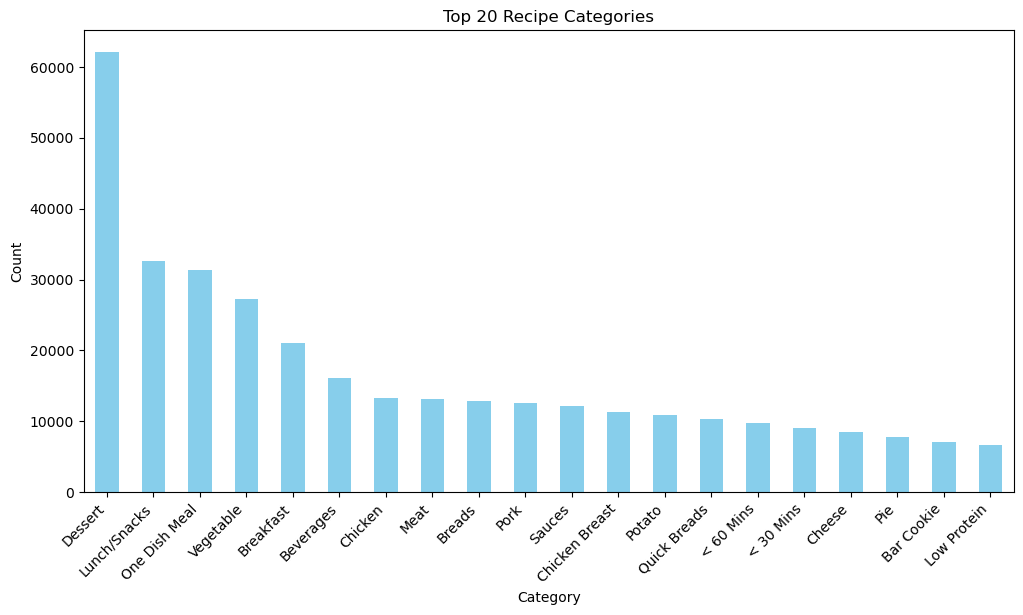

In [20]:
# 7. Recipe categories
print("Top 20 Recipe Categories:")
print(recipes['RecipeCategory'].value_counts().head(20))

plt.figure(figsize=(12, 6))
recipes['RecipeCategory'].value_counts().head(20).plot(kind='bar', color='skyblue')
plt.title('Top 20 Recipe Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

In [21]:
# 8. Nutrition field availability
nutrition_cols = ['Calories', 'FatContent', 'SaturatedFatContent', 'CholesterolContent', 
                  'SodiumContent', 'CarbohydrateContent', 'FiberContent', 'SugarContent', 'ProteinContent']

nutrition_missing = recipes[nutrition_cols].isnull().sum()
nutrition_availability = len(recipes) - nutrition_missing

print("Nutrition Field Availability (Number of Non-Null Entries):")
print(nutrition_availability)

print("\nNutrition Field Availability (%):")
print((nutrition_availability / len(recipes)) * 100)

Nutrition Field Availability (Number of Non-Null Entries):
Calories               522517
FatContent             522517
SaturatedFatContent    522517
CholesterolContent     522517
SodiumContent          522517
CarbohydrateContent    522517
FiberContent           522517
SugarContent           522517
ProteinContent         522517
dtype: int64

Nutrition Field Availability (%):
Calories               100.0
FatContent             100.0
SaturatedFatContent    100.0
CholesterolContent     100.0
SodiumContent          100.0
CarbohydrateContent    100.0
FiberContent           100.0
SugarContent           100.0
ProteinContent         100.0
dtype: float64


## Part 2: Full Dataset Analysis (`dataset/full_dataset.csv`)
This dataset contains a different schema focused on recipe instructions and text (e.g. ingredients, directions, NER). It does not contain user interactions, ratings, or nutrition data, but we can still perform basic EDA on it.

In [22]:
# Load full dataset
full_dataset = pd.read_csv('dataset/full_dataset.csv')
print(f"Total rows in full_dataset: {len(full_dataset)}")
full_dataset.head()

Total rows in full_dataset: 2231142


,Unnamed: 0,title,ingredients,directions,link,source,NER
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu..."
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom..."
2,2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""gar..."
3,3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroo..."
4,4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""peanut butter"", ""graham cracker crumbs"", ""bu..."


In [23]:
# Check missing values
print("Missing values in full_dataset:")
print(full_dataset.isnull().sum())

Missing values in full_dataset:
Unnamed: 0     0
title          1
ingredients    0
directions     0
link           0
source         0
NER            0
dtype: int64


Top Sources:
source
Gathered     1643098
Recipes1M     588044
Name: count, dtype: int64


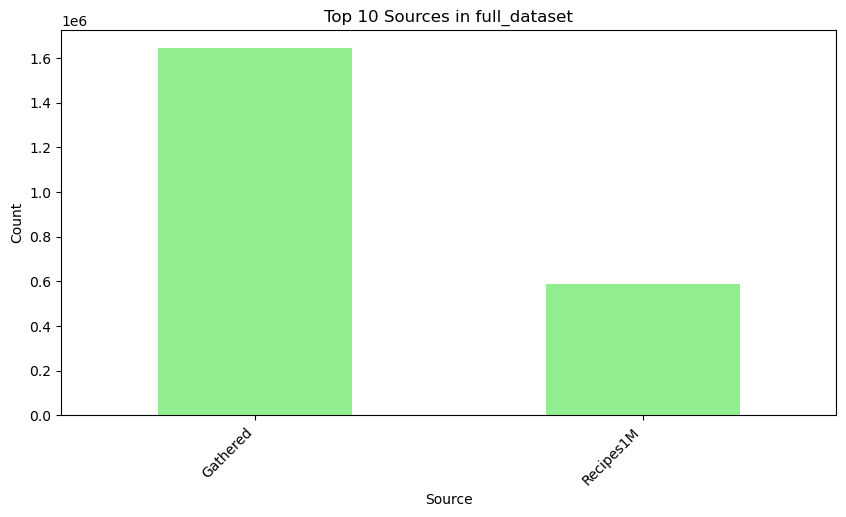

In [24]:
# Top sources in full dataset
if 'source' in full_dataset.columns:
    print("Top Sources:")
    print(full_dataset['source'].value_counts().head(10))
    
    plt.figure(figsize=(10, 5))
    full_dataset['source'].value_counts().head(10).plot(kind='bar', color='lightgreen')
    plt.title('Top 10 Sources in full_dataset')
    plt.xlabel('Source')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.show()